<a href="https://colab.research.google.com/github/MouseLand/cellpose/blob/main/notebooks/run_Cellpose-SAM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Run Cellpose-SAM - Stitched Image Version

Adapted from Marius Pachitariu, Michael Rariden, Carsen Stringer and the notebook by Pradeep Rajasekhar, inspired by the [ZeroCostDL4Mic notebook series](https://github.com/HenriquesLab/ZeroCostDL4Mic/wiki)

Designed for stitched global 5x4 2D images of 20 2160x20160 fields (roughly 10800x8140)

[paper](https://www.biorxiv.org/content/10.1101/2025.04.28.651001v1) | [code](https://github.com/MouseLand/cellpose)

### Make sure you are in the correct environment


In [1]:
# Check GPU and instantiate model - will download weights.
import numpy as np
from cellpose import models, core, io, plot
from pathlib import Path
from tqdm import trange
import matplotlib.pyplot as plt
import cv2 as cv 
import tifffile as tf
%matplotlib inline
from natsort import natsorted
from cellpose_functions import *


io.logger_setup() # run this to get printing of progress

#Check if GPU access




Welcome to CellposeSAM, cellpose v
cellpose version: 	4.0.6 
platform:       	linux 
python version: 	3.10.0 
torch version:  	2.7.0+cu126! The neural network component of
CPSAM is much larger than in previous versions and CPU excution is slow. 
We encourage users to use GPU/MPS if available. 


2025-07-12 18:58:40,185 [INFO] WRITING LOG OUTPUT TO /home/mattiazzilab/.cellpose/run.log
2025-07-12 18:58:40,186 [INFO] 
cellpose version: 	4.0.6 
platform:       	linux 
python version: 	3.10.0 
torch version:  	2.7.0+cu126


(<Logger cellpose.io (INFO)>,
 PosixPath('/home/mattiazzilab/.cellpose/run.log'))

In [2]:
if core.use_gpu()==False:
  raise ImportError("No GPU access, change your runtime")

model = models.CellposeModel(gpu=True)

2025-07-12 18:58:40,270 [INFO] ** TORCH CUDA version installed and working. **
2025-07-12 18:58:40,271 [INFO] ** TORCH CUDA version installed and working. **
2025-07-12 18:58:40,271 [INFO] >>>> using GPU (CUDA)
2025-07-12 18:58:41,197 [INFO] >>>> loading model /home/mattiazzilab/.cellpose/models/cpsam


Input directory with your images:
- Note - For best accuracy and runtime performance, resize images so cells are less than 100 pixels across

### set up the correct order for the image filenames - sort by location first, then channel
these functions moved to cellpose_functions
```python
def file_sort_key(filename):
  parts = filename.split("-")
  channel = parts[0][-1:] # get the last character of the first part
  location = parts[1]
  return (location,channel)

def plate_location(filename):
  parts = filename.split("-")
  pre_location = parts[1]
  location = pre_location.split(".")[0] # get the first part of the second part
  return location
  
#list all files
def sort_files(dir, image_ext):
  if not dir.exists():
    raise FileNotFoundError("directory does not exist")
  files = sorted([f for f in dir.glob("*"+image_ext) if "_masks" not in f.name and "_flows" not in f.name and "SUM" not in f.name],
                           key=lambda x: file_sort_key(x.name))```
 # sort by number in filename
  if(len(files)==0):
    raise FileNotFoundError("no image files found, did you specify the correct folder and extension?")
  else:
    return files
  
def print_files(files):
  for f in files:
    print(f.name)

def group_files_by_channel(files, nchannels=4):
  grouped = []
  for i in range(0,len(files),nchannels):
    grouped.append(files[i:i+nchannels])
  return grouped

def print_grouped_files(grouped):
  for i in range(len(grouped)):
    print(f"\n Group {i+1} of {len(grouped)}")
    for j in range(len(grouped[i])):
      item = grouped[i][j]
      print(" "+ item.name)
```

In [3]:
## For stitched images
image_ext = ".ome.tif"

stitched_path = Path("/mnt/bigdisk1/AllieSpangaro/Morphology_Replicative_Age_Project/stitching/segmentation_testset/")
stitched_path = Path(stitched_path)
if not stitched_path.exists():
  raise FileNotFoundError("directory does not exist")

# list all files
stitched_files = natsorted([f for f in stitched_path.glob("**/*"+image_ext) if "_masks" not in f.name and "_flows" not in f.name])
for f in stitched_files:
  print(f.name)
  #Make mask directory in the parent folder
  maskdir = f.parent / "masks"
  maskdir.mkdir(exist_ok=True)
  print(maskdir)
  
if(len(stitched_files)==0):
  raise FileNotFoundError("no image files found, did you specify the correct folder and extension?")
else:
  print(f"{len(stitched_files)} images in folder:")





r03c10_blockA.ome.tif
/mnt/bigdisk1/AllieSpangaro/Morphology_Replicative_Age_Project/stitching/segmentation_testset/R5/test_stitching/r03c10/Block_A/ashalr_img/masks
r03c10_blockB.ome.tif
/mnt/bigdisk1/AllieSpangaro/Morphology_Replicative_Age_Project/stitching/segmentation_testset/R5/test_stitching/r03c10/Block_B/ashalr_img/masks
r05c02_blockA.ome.tif
/mnt/bigdisk1/AllieSpangaro/Morphology_Replicative_Age_Project/stitching/segmentation_testset/R5/test_stitching/r05c02/Block_A/ashalr_img/masks
r05c02_blockB.ome.tif
/mnt/bigdisk1/AllieSpangaro/Morphology_Replicative_Age_Project/stitching/segmentation_testset/R5/test_stitching/r05c02/Block_B/ashalr_img/masks
r05c06_blockA.ome.tif
/mnt/bigdisk1/AllieSpangaro/Morphology_Replicative_Age_Project/stitching/segmentation_testset/R5/test_stitching/r05c06/Block_A/ashalr_img/masks
r05c06_blockB.ome.tif
/mnt/bigdisk1/AllieSpangaro/Morphology_Replicative_Age_Project/stitching/segmentation_testset/R5/test_stitching/r05c06/Block_B/ashalr_img/masks
r06c

## Run Cellpose-SAM on one image in folder

Here are some of the parameters you can change:

* ***flow_threshold*** is  the  maximum  allowed  error  of  the  flows  for  each  mask.   The  default  is 0.4.
    *  **Increase** this threshold if cellpose is not returning as many masks as you’d expect (or turn off completely with 0.0)
    *   **Decrease** this threshold if cellpose is returning too many ill-shaped masks.

* ***cellprob_threshold*** determines proability that a detected object is a cell.   The  default  is 0.0.
    *   **Decrease** this threshold if cellpose is not returning as many masks as you’d expect or if masks are too small
    *   **Increase** this threshold if cellpose is returning too many masks esp from dull/dim areas.

* ***tile_norm_blocksize*** determines the size of blocks used for normalizing the image. The default is 0, which means the entire image is normalized together.
  You may want to change this to 100-200 pixels if you have very inhomogeneous brightness across your image.
### Channel Selection
If you have a fluroescent image with multiple stains, you should choose one channel with a cytoplasm/membrane stain, one channel with a nuclear stain, and set the third channel to None. Choosing multiple channels may produce segmentaiton of all the structures in the image. If you have retrained the model on your data with a thrid stain (described below), you can run segmentation with all channels.

\n if you want to combine two stains to create your "cytoplasm" channel:
- Combine indices 0 and 2 (1st and 3rd) with two cellular stains
- and nuclei are in index 3 (4th channel)


In [4]:
first_channel = '0' # @param ['None', 0, 1, 2, 3, 4, 5]
second_channel = '1' # @param ['None', 0, 1, 2, 3, 4, 5]
third_channel = '3' # @param ['None', 0, 1, 2, 3, 4, 5]
channel_axis = 0

channels =  ["LAMP1",
            "MitoTracker",
            "Phalloidin",
            "DAPI"]

# If using a format with ch as the last dimension, Initialize with zeros for two channels

your image has shape: (4, 8640, 10800). Assuming channel dimension is first with 4 channels
uint16
ImageName: r03c10_blockA.ome.tif 
 pages: 4 
 dtype: uint16 
 page axes: YX 
 number of series: 1 
 shape: (4, 8640, 10800) 
 format: CYX 
 number of pyramid levels: 5 
 series dtype: uint16


"\nwith TiffFile('temp.ome.tif') as tif:\n...     baseimage = tif.series[0].asarray()\n...     second_level = tif.series[0].levels[1].asarray()\n...     number_levels = len(tif.series[0].levels)  # includes base level\n"

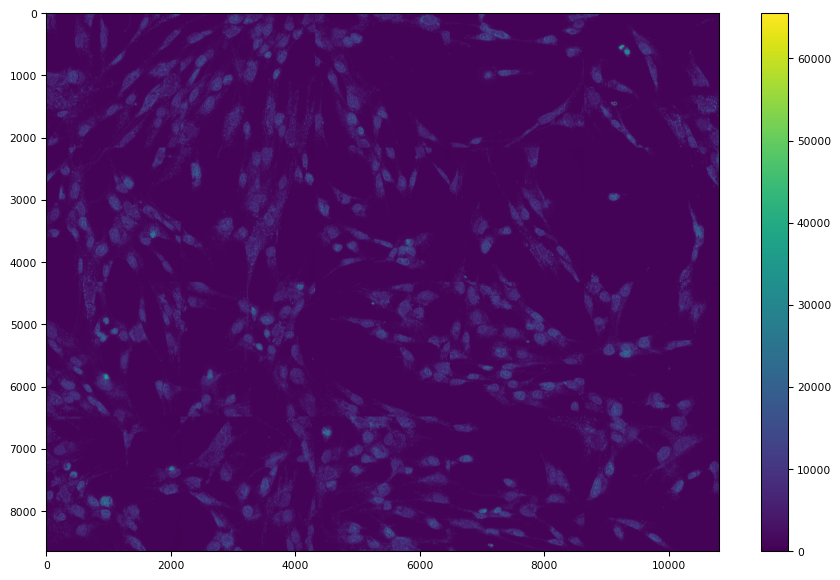

In [6]:
stitched_img = io.imread(stitched_files[0])
print(f'your image has shape: {stitched_img.shape}. Assuming channel dimension is first with {stitched_img.shape[0]} channels')

selected_channels = []
#For a multichannel stitched image in n,x,y format
channel_axis = 0
for i, c in enumerate([first_channel, second_channel, third_channel]):
  if c == 'None':
    continue
  if int(c) > stitched_img.shape[channel_axis]:
    assert False, 'invalid channel index, must have index greater or equal to the number of channels'
  if c != 'None':
    selected_channels.append(int(c))

#amplify the channel 1 image
stitched_img[1] = 2*stitched_img[1]
#img_selected_channels = np.zeros_like(img)
#img_selected_channels[:, :, :len(selected_channels)] = img[:, :, selected_channels]



pre_used_channel_img = np.stack((stitched_img[[0,1]].sum(axis=channel_axis, dtype=np.uint16), stitched_img[channels.index("DAPI")]), axis=channel_axis)
#pre_used_channel_img = np.stack(((stitched_img[0]+stitched_img[1]), stitched_img[channels.index("DAPI")]), axis=channel_axis)
print(pre_used_channel_img.dtype)

img_channel = pre_used_channel_img.astype(np.float32)
img_channel /= img_channel.max()  # or use a fixed value if you know the max
#tf.imshow(img_channel)
tf.imshow(pre_used_channel_img[0]+pre_used_channel_img[1])


#set_name = get_image_set_name(stitched_files)
#print("Set name: ", set_name)
#display(in_channels)

def get_tif_image_info(img_path):
    tif = tf.TiffFile(img_path)
    npages = len(tif.pages) # number of pages in the file
    page = tif.pages[0]  # get shape and dtype of image in first page
    dtype=page.dtype
    axes = page.axes

    series = tif.series[0]  # get shape and dtype of first image series
    nseries = len(tif.series)
    series_shape = series.shape
    series_type = series.dtype
    series_axes = series.axes
    series_pyramid_levels = len(series.levels)

    ome_metadata = tif.ome_metadata
    info = f"ImageName: {tif.filename} \n pages: {npages} \n dtype: {dtype} \n page axes: {axes} \n number of series: {nseries} \n shape: {series_shape} \n format: {series_axes} \n number of pyramid levels: {series_pyramid_levels} \n series dtype: {series_type}"
    tif.close()
    return info

print(get_tif_image_info(stitched_files[0]))

#NOTE: for pyramids, use level in the imread reader for tifffile
# first_level = (tf.imread(stitched_files[0], series=0, level=0))
# second_level = (tf.imread(stitched_files[0], series=0, level=1))
# print(first_level.shape)
# print(second_level.shape)

'''
with TiffFile('temp.ome.tif') as tif:
...     baseimage = tif.series[0].asarray()
...     second_level = tif.series[0].levels[1].asarray()
...     number_levels = len(tif.series[0].levels)  # includes base level
'''


In [6]:
#Otherwise, group files by channel first
def file_sort_key(filename):
  '''
    Generate a key to sort a list of image files in the 'MAX_chN-rXXcYYfZZ.tif' filename nomenclature by their plate location and channel.
    > e.g: MAX_ch1-r02c02f01.tif, MAX_ch2-r02c02f01.tif, MAX_ch3-r02c02f01.tif, MAX_ch3-r02c02f01.tif, MAX_ch1-r02c02f02.tif, MAX_ch2-r02c02f02.tif, MAX_ch3-r02c02f02.tif, MAX_ch3-r02c02f02.tif
    Parameters:
          filename (str): the filename from the image path
    Returns:
          (location,channel) (tuple of str): the list of files sorted by location and channel. Images will be ordered by location first, and then by channel to match the order seen in CellProfiler  
  '''
  parts = filename.split("-")
  channel = parts[0][-1:] # get the last character of the first part for the channel number
  location = parts[1] #get the rXXcYYfZZ.tif portion
  return (location,channel)

def sort_files(dir, image_ext):
  '''
    Sort the list of directories sorted by their plate location and channel 
    Parameters:
          dir (Path object or str): the directory containing the images
          image_ext (str, optional): the image extension, tif by default
    Returns:
          files (list of Path objects): the list of files sorted by location and channel  
  '''
  if not dir.exists():
    raise FileNotFoundError("directory does not exist")
  files = sorted([f for f in dir.glob("*"+image_ext) if "_masks" not in f.name and "_flows" not in f.name and "SUM" not in f.name],
                           key=lambda x: file_sort_key(x.name))
 # sort by number in filename
  if(len(files)==0):
    raise FileNotFoundError("no image files found, did you specify the correct folder and extension?")
  else:
    return files

def group_files_by_channel(files, nchannels=None):
  '''
    Load the list of directories
    Parameters:
          dir (Path object or str): the directory containing the images
          nchannels (int,optionsl): the number of image channels to use for grouping
    Returns:
          grouped_files_by_channel (2D list of Path objects): list of files grouped into image sets by their channels
  '''
  grouped_files_by_channel = []
  if nchannels==None:
    nchannels = get_nchannels(files)
    
  for i in range(0,len(files),nchannels):
    grouped_files_by_channel.append(files[i:i+nchannels])
  return grouped_files_by_channel

(2, 8640, 10800)
(8640, 10800, 2)
Preprocessed stitched image shape: (8640, 10800, 2)


(<Figure size 988.8x604.8 with 2 Axes>,
 <Axes: >,
 <matplotlib.image.AxesImage at 0x7f377819f250>)

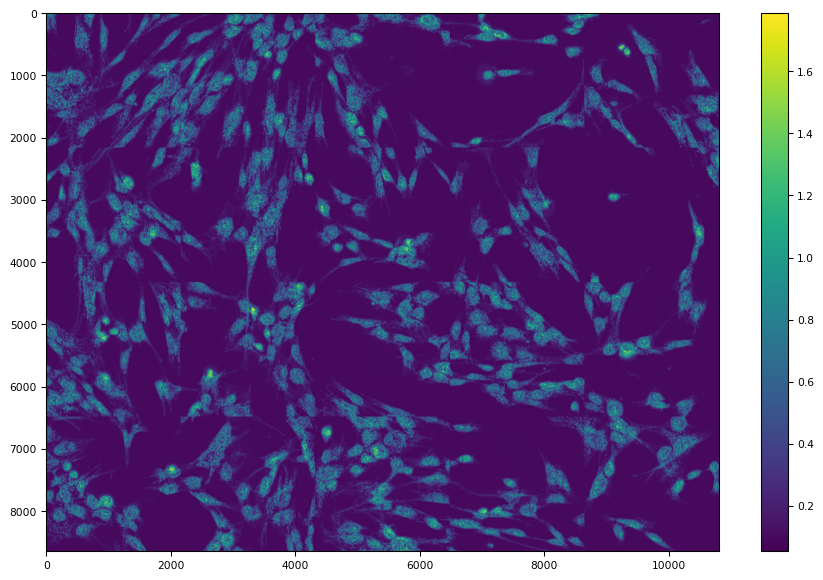

In [7]:
og_img_shape = pre_used_channel_img.shape
print(og_img_shape)
#tf.imshow(stitched_img[3,:,:])

#preprocessed_stitch = np.stack([np.zeros_like(stitched_img[0]), np.zeros_like(stitched_img[0])], axis=-1) 
#convert image to the (height, width, channels) shape for scikit-image functions
if og_img_shape[0] < 5:
    used_channel_img = np.transpose(pre_used_channel_img, (1,2,0)) 
    print(used_channel_img.shape)
    channel_axis =-1
else:
    used_channel_img = pre_used_channel_img
    

from skimage import exposure, filters, morphology

preprocessed_image_channels = []
for i in range(2):#range(used_channel_img.shape[-1]):
    img_channel = used_channel_img[:,:,i]
    if img_channel is None:
        print(f"Channel {i} is None, skipping.")
        continue
    #footprint = morphology.disk(5)
    #channel = img_01_normalization(channel)
    img_channel = exposure.equalize_adapthist(img_channel, kernel_size=100, clip_limit=0.05)
    img_channel = filters.gaussian(img_channel, sigma=2)
    preprocessed_image_channels.append(img_channel)

preprocessed_stitched_img = np.stack(preprocessed_image_channels, axis=-1)

# preprocessed_stitched_img = np.zeros_like(used_channel_img)
# for i in range(used_channel_img.shape[-1]):
#     img_channel = used_channel_img[:,:,i].copy()
#     if img_channel is None:
#         print(f"Channel {i} is None, skipping.")
#         continue
#     #img_channel = img_01_normalization(img_channel)
#     img_channel = exposure.equalize_adapthist(img_channel, kernel_size=100, clip_limit=0.05)
#     img_channel = filters.gaussian(img_channel, sigma=2)
    
#     preprocessed_stitched_img[:,:,i] = img_channel
    
    
print("Preprocessed stitched image shape:", preprocessed_stitched_img.shape)
#rescaled_stitch = img_rescaled(preprocessed_stitched_img, factor=0.3, channel_axis=0)
#img_channel = img_channel.astype(np.float32)
#img_channel /= img_channel.max()  # or use a fixed value if you know the max
tf.imshow(preprocessed_stitched_img[:,:,0]+preprocessed_stitched_img[:,:,1])

In [ ]:
def preprocess_stitch_with_channel_third_dimension(stitched_img):
    preprocessed_stitch = np.stack([np.zeros_like(stitched_img[0]), np.zeros_like(stitched_img[0])], axis=-1)  

    for i, channel in enumerate(stitched_img):
        img_channel = stitched_img[i]
        if img_channel is None:
            print(f"Channel {i} is None, skipping.")
            continue
        if i == 1:
            prev_img_channel = stitched_img[0]
            open_imgs = [prev_img_channel, img_channel]
            for i, ch in enumerate(open_imgs):
                ch = img_01_normalization(ch)
                ch = exposure.equalize_adapthist(ch, kernel_size=100, clip_limit=0.05)
                ch = filters.gaussian(ch, sigma=2)
                open_imgs[i] = ch
            combined_channels = open_imgs[0] + (2*open_imgs[1]) 
            preprocessed_stitch[:,:,0] = combined_channels
        if i == 3:
            img_channel = img_01_normalization(img_channel)
            img_channel = exposure.equalize_adapthist(img_channel, kernel_size=100, clip_limit=0.05)
            img_channel = filters.gaussian(img_channel, sigma=2)
            preprocessed_stitch[:,:,1] = img_channel
    
    print("Preprocessed stitched image shape:", preprocessed_stitch.shape)
    rescaled_stitch = img_rescaled(preprocessed_stitch, factor=0.3)
    #tf.imshow((rescaled_stitch [:,:,0] + rescaled_stitch [:,:,1]))
    return rescaled_stitch

2025-07-12 18:26:34,988 [INFO] No cell pixels found.


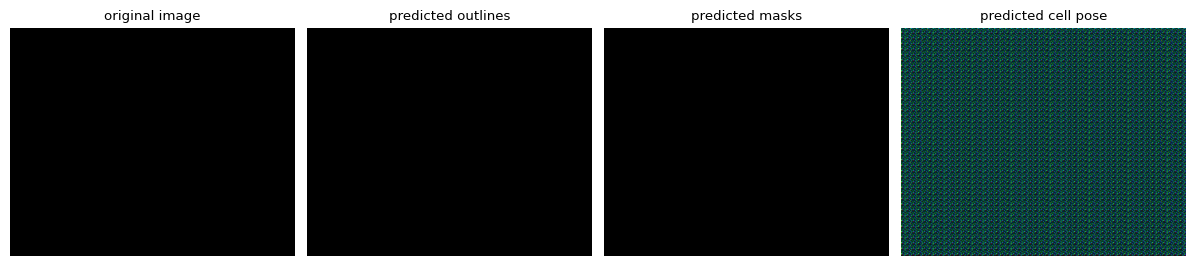

In [18]:
flow_threshold = 0.6
cellprob_threshold = -1
tile_norm_blocksize = 0
diameter = None
show = True

masks, flows, styles = model.eval(preprocessed_stitched_img, batch_size=32, diameter=diameter, flow_threshold=flow_threshold, cellprob_threshold=cellprob_threshold,
                                normalize={"tile_norm_blocksize": tile_norm_blocksize})
#plot if true
if show:
    fig = plt.figure(figsize=(12,5))
    plot.show_segmentation(fig, preprocessed_stitched_img, masks, flows[0])
    plt.tight_layout()
    plt.show()

def segment_cell_stitchedimg(img, show=True):
    from skimage import exposure,filters,morphology
    gfp = img[:,:,0] #combine the ch1 and ch2 images to help cellpose out a bit
    rfp = img[:,:,1]
    dapi = img[:,:,2] #save ch3 for later
    
    img_combo = gfp+rfp
    img_combo = img_01_normalization(img_combo) #normalize to match cellpose training data
    #adjust contrast
    img_combo = exposure.equalize_adapthist(img_combo, kernel_size=68, clip_limit=0.01)
    #smooth and subtract background
    dog = filters.difference_of_gaussians(img_combo, low_sigma=2.5)
    img_combo = img_combo - dog
    
    #sharpen image and improve outline
    img_combo = filters.unsharp_mask(img_combo, radius=2, amount=1)
    
    #stack the images
    img_selected_channels = np.stack([img_combo, dapi],axis=-1)
    
    """ fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12,5),sharex=True, sharey=True)
    ax1.imshow(img_selected_channels[:,:,0])
    ax2.imshow(img_selected_channels[:,:,1]) """
     
    flow_threshold = 0.6
    cellprob_threshold = -1
    tile_norm_blocksize = 0
    diameter = 40

    masks, flows, styles = model.eval(img_selected_channels, batch_size=32, diameter=diameter, flow_threshold=flow_threshold, cellprob_threshold=cellprob_threshold,
                                    normalize={"tile_norm_blocksize": tile_norm_blocksize})
    #plot if true
    if show:
        fig = plt.figure(figsize=(12,5))
        plot.show_segmentation(fig, img_selected_channels, masks, flows[0])
        plt.tight_layout()
        plt.show()
    return masks
    
def segment_nuclei_tweaking_stitchedimg(orig_img, show=True):
    from skimage import morphology, filters
    img = orig_img[:,:,2] # get the DAPI channel
    
    # remove background
    dog = filters.difference_of_gaussians(img, low_sigma=2.5)
    seed = np.minimum(dog, img)  # ensure seed is not greater than the original image
    bg = morphology.reconstruction(seed, img, method='dilation')
    img = img - bg
    
    # remove speckle-shaped autofluor
    bg2 = morphology.white_tophat(img, morphology.disk(3))
    img = img - bg2
    img = morphology.closing(img, morphology.disk(2.5))
    img = filters.gaussian(img, sigma=1)
    #img = img_01_normalization(img)
    
    flow_threshold = 0.5
    cellprob_threshold = 0
    tile_norm_blocksize = 0
    diameter = None

    masks, flows, styles = model.eval(img, batch_size=32, diameter=diameter, flow_threshold=flow_threshold, cellprob_threshold=cellprob_threshold,
                                    normalize={"tile_norm_blocksize": tile_norm_blocksize})
    if show:
        fig = plt.figure(figsize=(24,6))
        plot.show_segmentation(fig, img, masks, flows[0])
        plt.tight_layout()
        plt.show()
    return masks


In [ ]:
img = img2
from skimage import feature, filters   
cell_masks = segment_cell(img,model)
nuc_masks = segment_nuclei(img,model)
cell_v2_masks = segment_cell_v2(img,model)

#smoothed_masks = filters.unsharp_mask(cell_masks, radius=1).astype(uint)
#smoothed_masks = (smoothed_masks > 0.5).astype(int)  # Binarize the smoothed masks

save_masks(set_name+"diam", cell_masks, outdir=maskdir, image_ext=image_ext)
print(maskdir)
#save_masks(set_name+"smooth", smoothed_masks, outdir=maskdir, image_ext=image_ext)
#save_masks(set_name, nuc_masks, outdir=maskdir, image_ext=image_ext, mask_type="nuclei")
#blobs = filters.median(img[:,:,1])
#tf.imshow(blobs)

## Run Cellpose-SAM on folder of images

if you have many large images, you may want to run them as a loop over images
See `cellpose_functions` to run this
 moved to `save_mask_folder() `


In [ ]:
for dir in dirlist:
    maskdir = dir / "masks"
    maskdir.mkdir(exist_ok=True)
    #nchannels = 4
    if dir.name != "20250328":#the folders that are already done
        continue
    else:
        # if dir.name == "20241112":
        #     nchannels = 3
        # else:
        #     nchannels = 4
        print("writing to: " + str(maskdir))
        files = load_sorted_directory_list(dir)
        
        save_mask_folder(files,maskdir,v2=True)



### loop for all files in the group in the directory
```python
for i in trange(len(grouped_files)):
    file_group = grouped_files[i]
    img_set = load_image_set(file_group)
    img_set_name = get_image_set_name(file_group)
    print("Set name: ", set_name)
    
    stacked_img = img_preprocessing(img_set)
    rescaled_img = img_rescaled(stacked_img, factor=0.25)
    
    cell_masks = segment_cell(rescaled_img, show=False)
    nuc_masks = segment_nuclei(rescaled_img, show=False) 
    
    save_masks(img_set_name, cell_masks, image_ext=image_ext)
    save_masks(img_set_name, nuc_masks, image_ext=image_ext, mask_type="nuclei") 
```